In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

# Take only 2 features to make visualization easier
# Feature MedInc has a long tail distribution.
# Feature AveOccup has a few but very large outliers.
features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

# scale the output between 0 and 1 for the colorbar
y = minmax_scale(y_full)

# plasma does not exist in matplotlib < 1.5
cmap = getattr(cm, "plasma_r", cm.hot_r)


def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # define the axis for the zoomed-in plot
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")

In [2]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

### Datos Originales
- Para los datos originales, en el grafico de la izquierda, se puede apreciar que existen claramente outliers tanto para "Average house occupancy" como para "Median income in block", en el grafico de la derecha, se eliminan esos outliers dando como resultado un grafico mas acotado entre los valores en los cuales se concentran la mayor cantidad de datos, para "Average house occupancy", va desde 0 a 5, muy lejos de los 500 que se observaba en el grafico ampliado y para "Median income in block" entre 0 y 10, no es tan lejano a los 14 que se observaban en el primer grafico, pero si se puede apreciar que los datos que estaban entre 10 y 14 eran muy pocos.

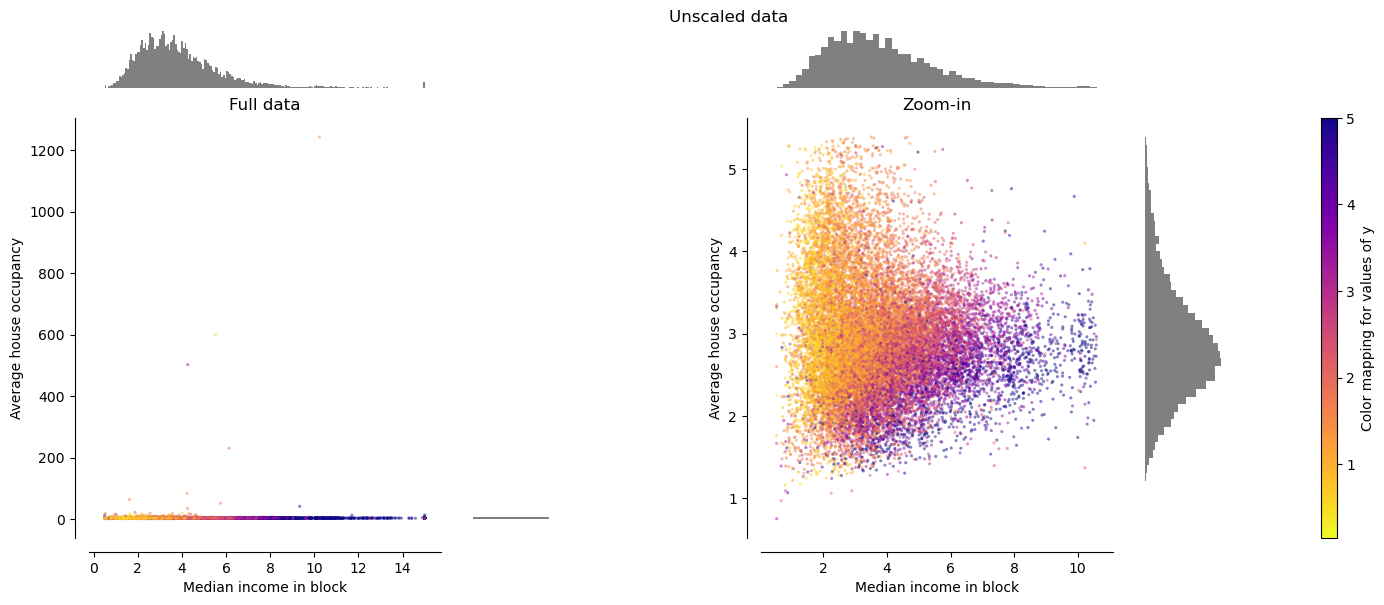

In [3]:
make_plot(0)

### Standard Scaler
- En cuanto a los valores, para los datos enteros, pareciera dividirse por 10 la escala en comparacion con los datos sin procesar. Para los datos ampliados, en 'Average house occupancy', los datos se escalan entre -1 y 1. Los outliers para 'Average house occupancy', que superan el valor 0.2 son eliminados del modelo asi como para 'Median income in block' que superan el valor de 3, son eliminados del modelo.


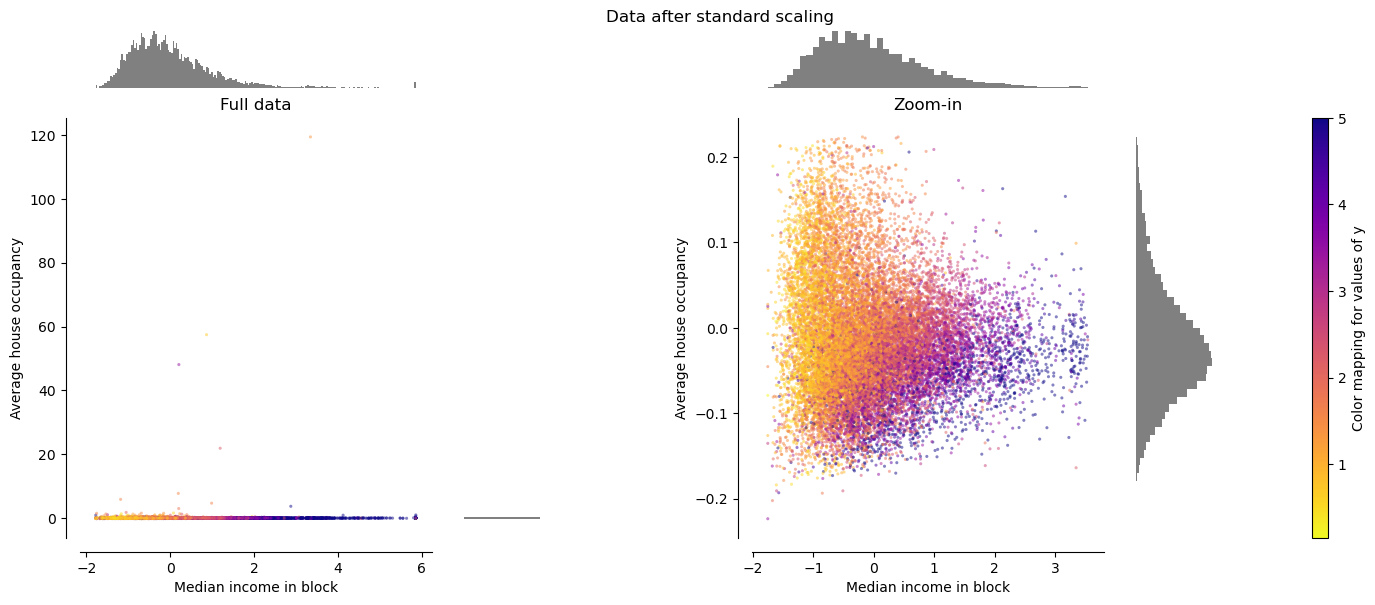

In [4]:
make_plot(1)

### Min Max Scaler
- Los datos son escalados en los valores entre 0 y 1. Para los datos ampliados, la escala se reduce mas todavia, esta se encuentra entre los valores 0 y 0.0035 para 'Average house occupancy' y entre 0 y 0.7 para 'Median income in block'. En cuanto a los outliers, para 'Average house occupancy', se eliminan todos los valores que superan 0.0035, mientras que para 'Median income in block', la reduccion no es tan drastica ya que elimina los valores que superan 0.7 de un valor maximo de 1.

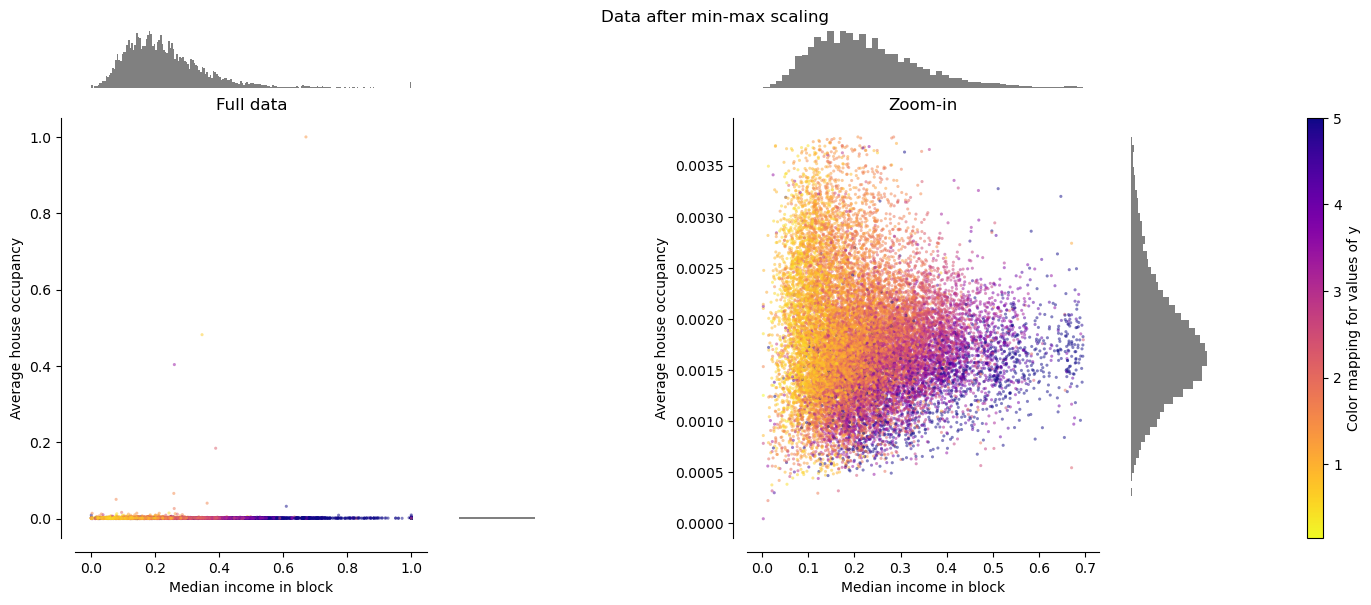

In [5]:
make_plot(2)

### Max Abs Scaler
- Tanto para los datos enteros como para los datos ampliados, Mix Abs Scaler, funciona de manera similar a Mix Max Scaler.

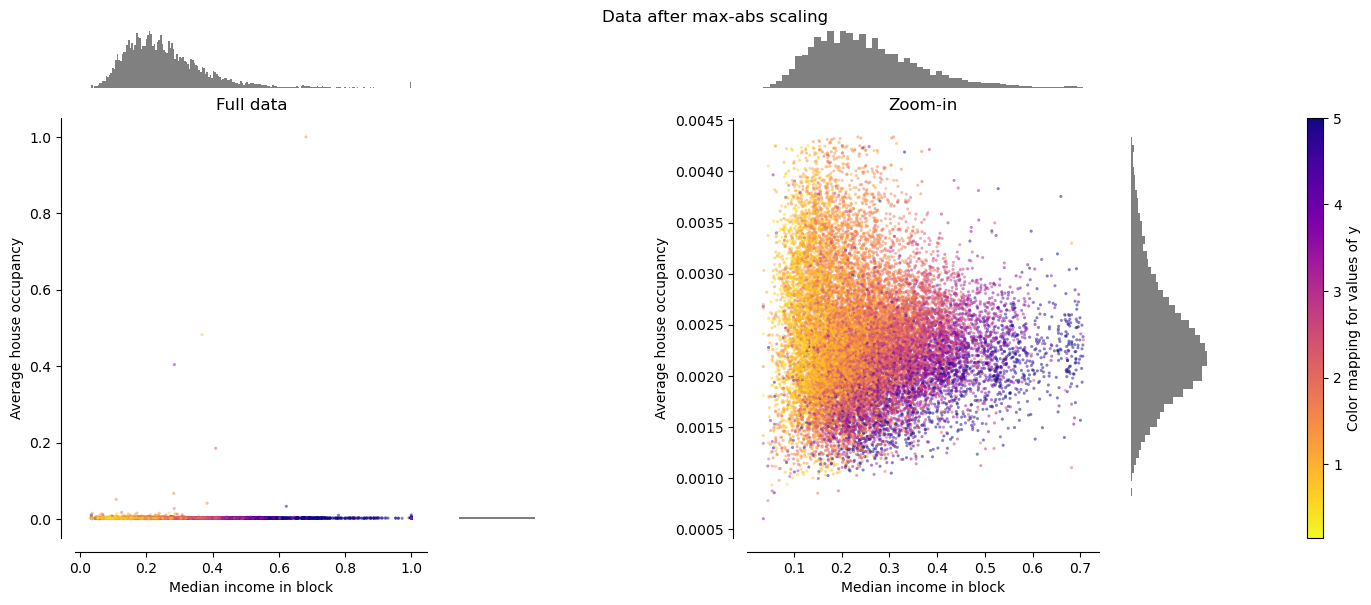

In [6]:
make_plot(3)

### Robust Scaler
- El escalador mantiene los datos completos igual que como estaban antes del escalado para 'Average house occupancy', pero para 'Median income in block', acorta la escala. Para los datos ampliados, si se ve diferencia en cuanto a los datos originales, para ambos casos, las escalas no superan el valor de 3. En cuanto a outliers, para 'Average house occupancy', para los datos completos, no se aprecia una gran reduccion de los mismos respecto de los datos originales, pero para los datos ampliado, se reduce una gran cantidad de datos, ya que no superan el valor de 3, para 'Median income in block', la reduccion de outliers para los datos tanto completos como para los datos ampliados, es fuerte ya que se reduce del valor 14 a 5 y 3 respectivamente.

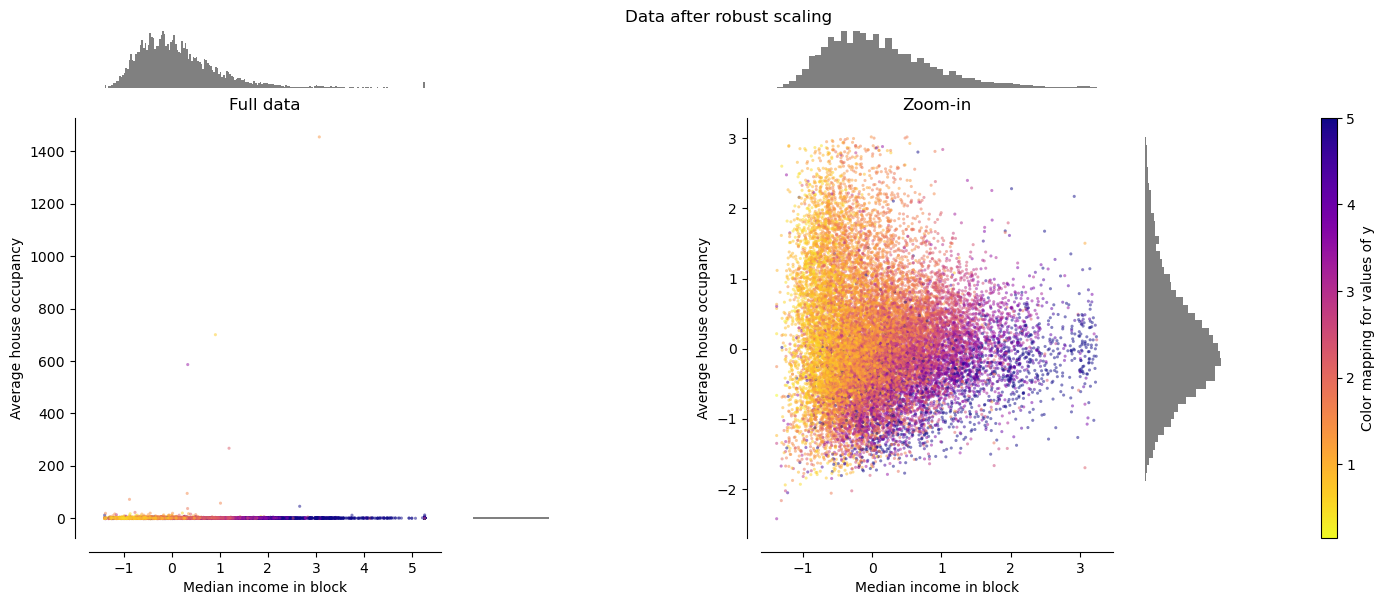

In [7]:
make_plot(4)

### Power Transformation (Yeo-Johnson) y Power Transformation (Box Cox)
- Tanto para la version de Yeo-Johnson como para Box Cox, las escalas en comparacion con los datos sin procesar, son ampliamente reducidas. Para el primer caso, para 'Average house occupancy', la escala se reduce entre '6 y 6 y para 'Median income in block' se reduce entre -3 y 3 y para los datos ampliados, va de entre -6 a 2 para el primer caso y entre -3 y 2 en el segundo. En cuanto a los outliers, se ve bastante distribuido dentro de la escala, no se ha elimnado por completo. En cuanto a Box Cox, todo funciona de manera similar a Yeo-Johnson, pero en los datos completos, para 'Average house occupancy', la escala va desde -8 a 8.

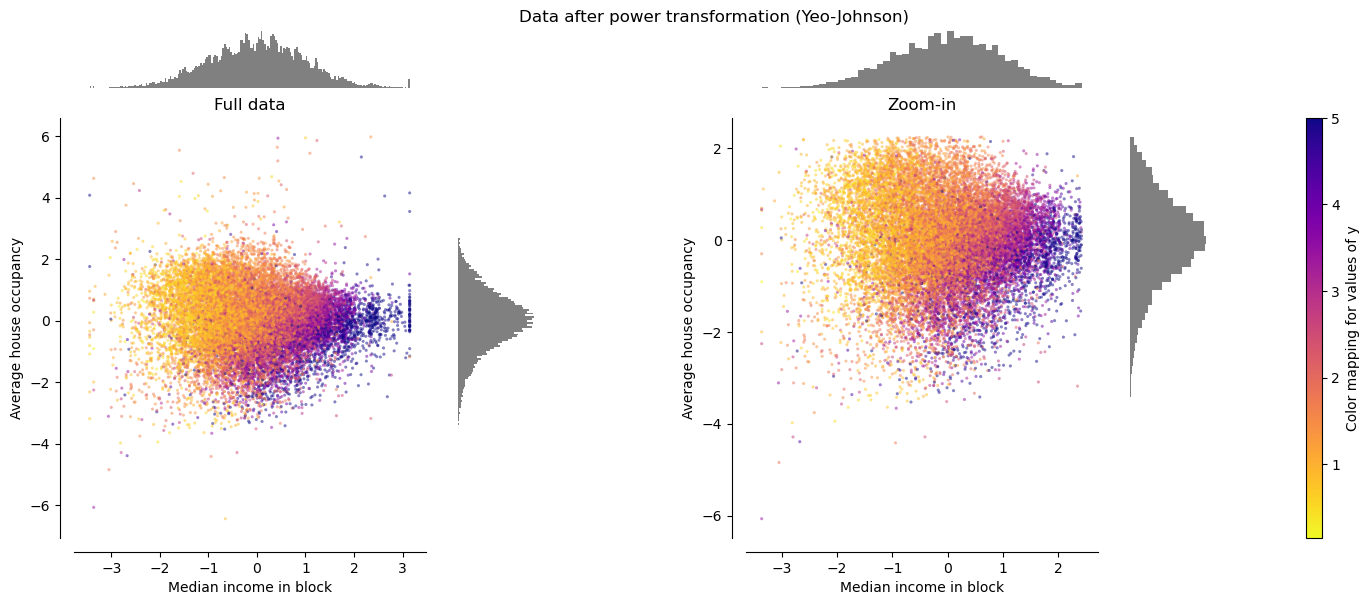

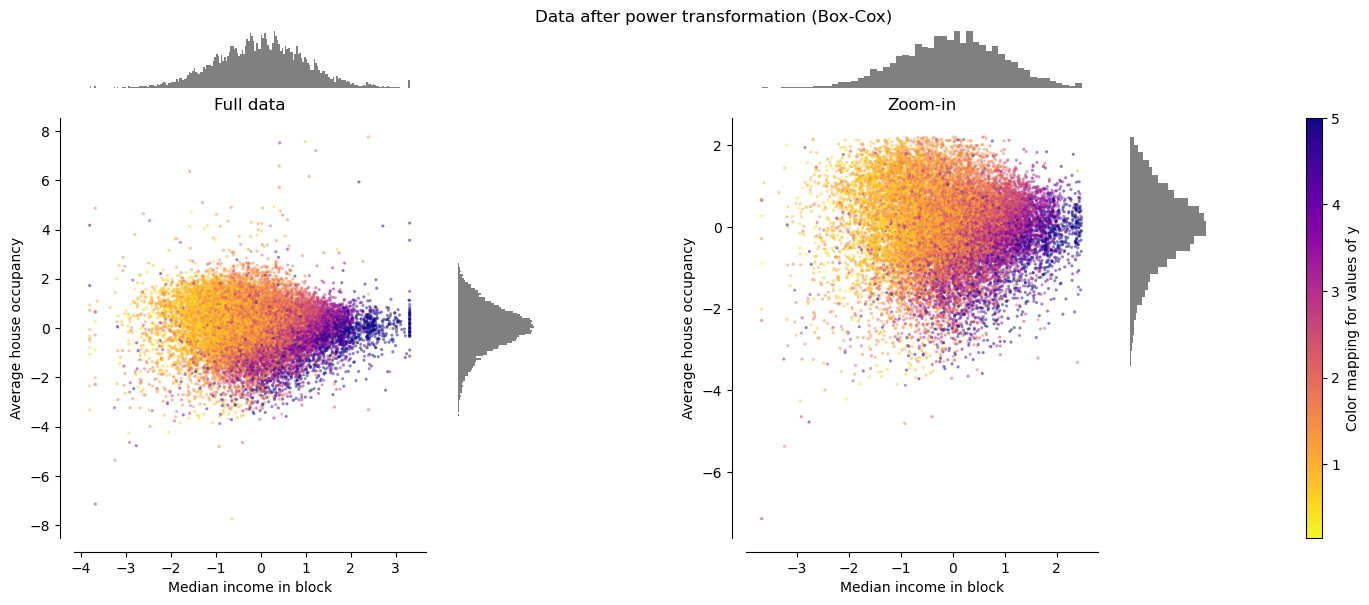

In [8]:
make_plot(5)
make_plot(6)

### Quantile Transformation (Uniform PDF)
- En este caso, ambas variables se escalan entre los valores 0 y 1, tanto para los datos completos como ampliados. En comparacion a los datos sin procesar, se observa una enorme reduccion en la escala. Para los outliers, no pareciera que se eliminen del modelo.

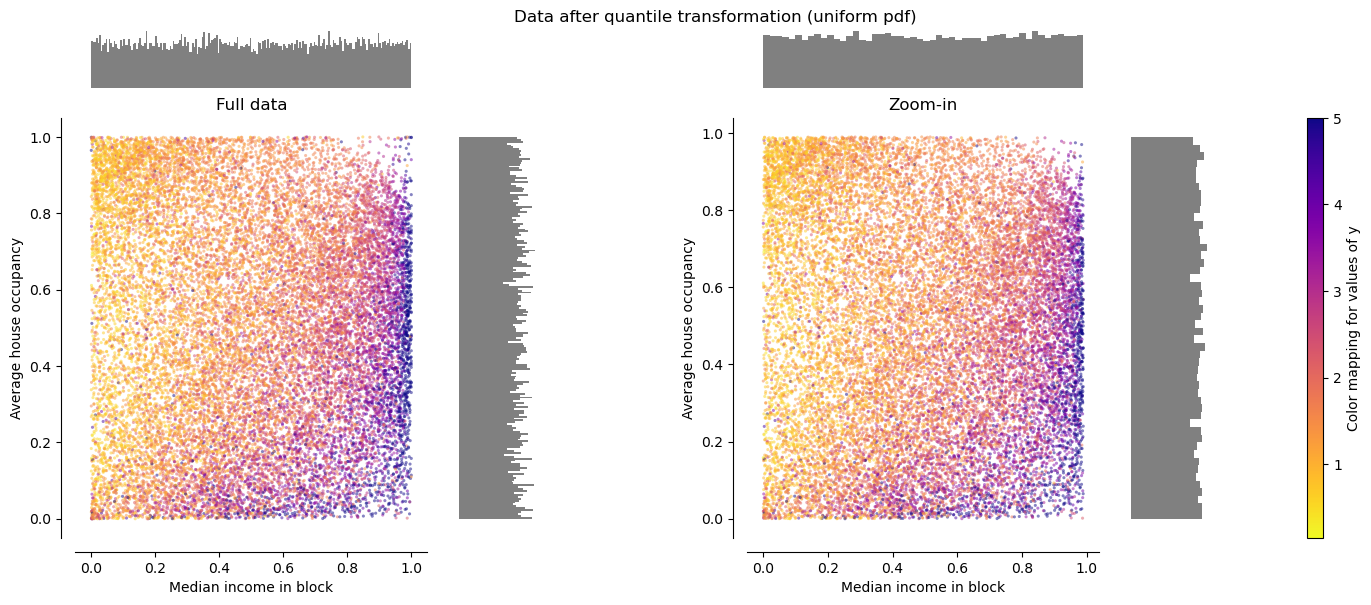

In [9]:
make_plot(7)

### Quantile Transformation (Gaussian PDF)
- En este caso, las escalas se reducen notablemente en comparacion a los datos sin escalar. Para los datos completos, las escalas para las dos variables van de -4 hasta 4, se pueden apreciar outliers en los valores extremos. Para los datos ampliados, la escala va desde -3 hasta 2, con eliminacion de los outliers que se encontraban en los extremos en la vista general de los datos. 

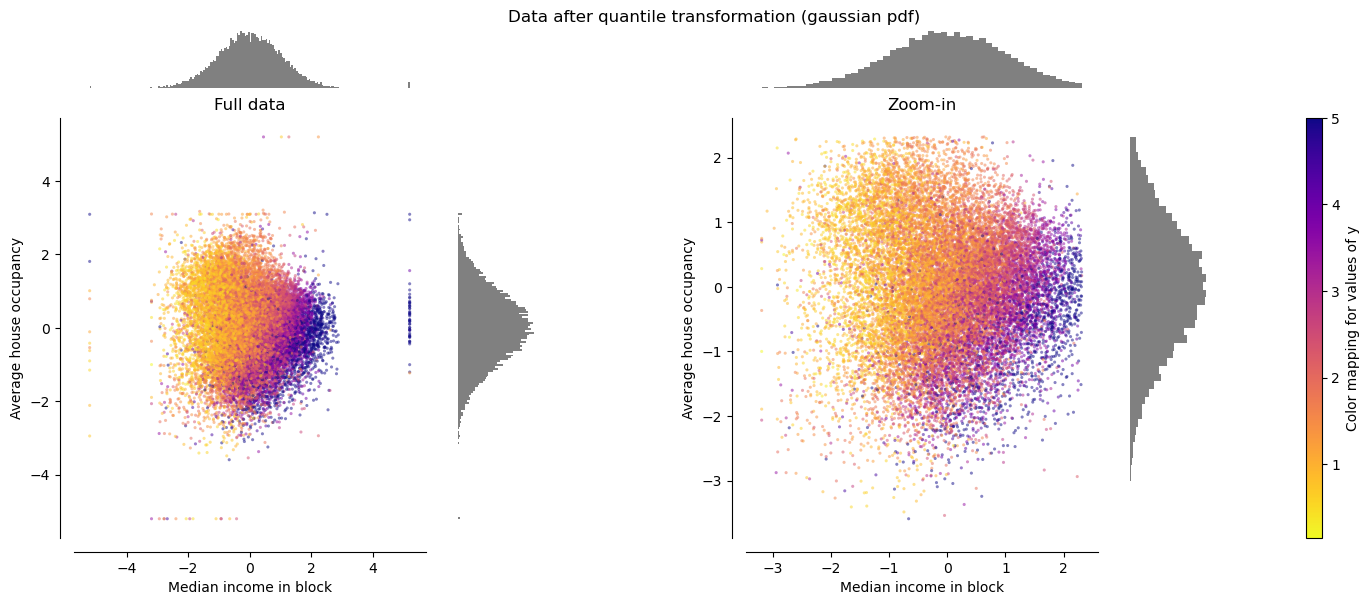

In [10]:
make_plot(8)

### Sample-Wise L2 Normalizing
- Para los datos completos, el escalado se reduce drasticamente, la escala va desde 0 hasta 1 y los datos se normalizan entre esos valores. En el caso de los datos ampliados, la escala se reduce aun mas, eliminando del modelo a los datos que se encuentran en los extremos.

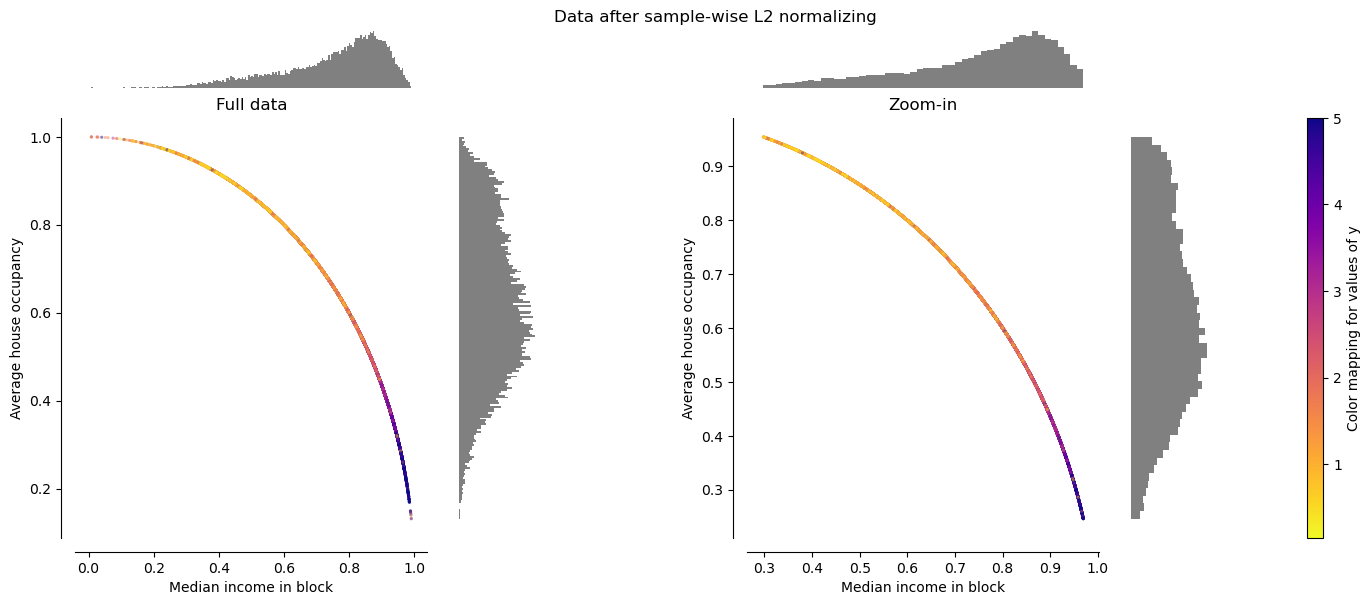

In [11]:
make_plot(9)

plt.show()

### Cuestionario 
**1. Sensibilidad a los valores atípicos**

Observa las gráficas de StandardScaler y MinMaxScaler. ¿Qué sucede con la masa principal de los datos (el "cuadrado" denso) cuando hay valores atípicos muy alejados? ¿Por qué estos escaladores podrían ser problemáticos en este escenario?

**2. Robustez**

Compara el RobustScaler con el StandardScaler. Explica por qué el RobustScaler logra mantener el "zoom" en la mayoría de los datos a pesar de que los ejes sigan mostrando los valores extremos. ¿Qué estadísticos utiliza para lograr esto?

**3. Normalización de la distribución**

El PowerTransformer (método Yeo-Johnson) y el QuantileTransformer (salida Gaussiana) intentan forzar los datos hacia una distribución normal.

¿Qué diferencias visuales notas entre ellos?

¿En qué tipo de modelos de aprendizaje automático crees que sería más beneficioso usar estas transformaciones en lugar de un simple escalado lineal?

**4. El caso del Normalizer**

El Normalizer muestra un gráfico muy distinto a todos los demás (con una forma circular o arqueada).

¿Por qué este escalador actúa sobre las filas (muestras) en lugar de las columnas (características)?

Investiga un caso de uso (como procesamiento de texto o química) donde este comportamiento sea deseable.

**5. Conclusión técnica**

Si estuvieras entrenando un modelo de regresión lineal para predecir el precio de las casas y notas que la variable "ingreso medio" tiene muchos valores atípicos, ¿cuál de todos los métodos probados elegirías y por qué?

### Respuestas

**1.** En ambos casos, los valor atipicos (outliers) entran en el modelo. Esto podría ser problematico ya que, al entrenar el modelo, puede arrojar un valor erroneo, sesgado por estos outliers.

**2.** El Robust Scaler logra un escalado menor al que de Standard Scaler. En el zoom, Robust Scaler, todos los valores entran en la escala, mientras que para Standard Scaler, los valores son eliminados del modelo, dejando solo los que estan dentro de la escala.

**3.** A simple vista, la diferencia, se basa en que en Power Transformer (Yeo-Johnson) se escalan tambien los outliers mientras que en Quantile Transformer, la escala esta entre 0 y 1, por lo tanto, en el primero se observan outliers con facilidad, mientras que en el segundo los datos se encuentran dentro de la escala.
Ambos metodos son interesantes de utilizar en aprendizaje no supervisado, ya que intentan forzar la distribucion, importante a la hora de encontrar patrones o tendencias.

**4.** En una cita encontrada en internet, se postula:
*"El objetivo principal de sklearn.preprocessing.Normalizer no es escalar características a un rango (como hacen StandardScaler o MinMaxScaler en columnas), sino ajustar la magnitud de cada muestra individualmente para que la norma (la longitud del vector) sea igual a 1."*

Caso de uso: Un caso de uso fundamental donde este comportamiento es necesario es en la clasificación de documentos o búsqueda de similitud (NLP) utilizando representaciones vectoriales como TF-IDF o bolsas de palabras (Bag of Words).

**5.** Eligiria Robust Scaler ya que es el metodo que pareciera menos sensible a los outliers, los incluye en el escalado, sino se correria el riesgo de eliminar del modelo a muchos datos que no es que no sean reales, sino que realmente existen y que son muy diversos.